# 핵심 결과 — DepMap Mutation 기반 유전체 불안정성 예측

DepMap mutation만으로 WGD/CIN/LOH를 예측하고 최소 biomarker panel을 찾는
프로젝트의 핵심 결과만 간결하게 정리한 노트북이다. 전체 파이프라인은
`01_full_pipeline.ipynb`, 전체 문서는 https://github.com/lkeonwoo94/AI-bio-proj-team-1 참고.

## 0. 실행 환경 준비 (로컬 / Google Colab 공용)

아래 셀이 순서대로 처리한다.

1. **저장소** — 이미 저장소 안이면 그대로 쓰고, 아니면(Colab 등) `git clone` 한다.
   이 노트북은 `src/` 의 파이프라인 코드를 그대로 import 해서 쓴다. 그래야
   여기서 나오는 수치가 저장소 결과와 **구조적으로 같다** (코드가 두 벌이 아니다).
2. **데이터** — `data/interim/cohort_*.parquet` 또는 `data/depmap/*.csv` 가 로컬에
   있으면 그것을 쓰고, 없으면 **공개 Google Drive 폴더에서 내려받는다**.
   드라이브 *마운트* 가 아니라 다운로드라서, 폴더 주인이 아닌 사람도 그대로 실행된다.
3. **패키지·한글 폰트** — Colab 에 없는 것만 설치한다.

In [1]:
# --- 저장소 + 데이터 준비 ---
import os
import shutil
import time
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/lkeonwoo94/AI-bio-proj-team-1.git"
# 공개 폴더. 마운트가 아니라 다운로드라서 폴더 주인이 아니어도 받을 수 있다.
DRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/1WKn7V26f4ETRZgH_5TcjcIPdlO9L6j2h"

IN_COLAB = "google.colab" in sys.modules

RAW_FILES = ["OmicsSomaticMutationsMatrixHotspot.csv",
             "OmicsSomaticMutationsMatrixDamaging.csv",
             "OmicsGlobalSignatures.csv", "Model.csv"]
CACHE_FILES = ["cohort_X.parquet", "cohort_y.parquet", "cohort_groups.parquet"]
# signature(96-class) 행렬. 이미 만들어져 있어 hg38.2bit(800MB) 없이도 쓸 수 있다.
EXTRA_FILES = ["sbs96_signature_matrix.parquet"]
# TCGA 외부 검증용 파생 데이터. 이것도 이미 만들어져 있어 750MB MAF 없이 쓸 수 있다.
TCGA_FILES = ["tcga_damaging_matrix.parquet", "tcga_wgd_labels.parquet"]


def _find_repo_root():
    """src/ 와 results/tables 를 함께 가진 디렉터리를 저장소 루트로 본다."""
    for cand in (Path.cwd(), *Path.cwd().parents):
        if (cand / "src").is_dir() and (cand / "results" / "tables").is_dir():
            return cand
    return None


root = _find_repo_root()
if root is None:
    target = Path("/content/AI-bio-proj-team-1") if IN_COLAB else Path.cwd() / "AI-bio-proj-team-1"
    if not target.is_dir():
        print("저장소를 클론한다...")
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(target)], check=True)
    os.chdir(target)
    root = target

REPO_ROOT = root
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))   # src/ 를 import 하기 위해
print("REPO_ROOT:", REPO_ROOT)

DEPMAP = REPO_ROOT / "data" / "depmap"
INTERIM = REPO_ROOT / "data" / "interim"


def _have(directory, names):
    return all((directory / n).exists() for n in names)


def _copy_found(src_root, names, dest):
    """src_root 아래를 재귀 탐색해 이름이 맞는 파일을 dest 로 옮긴다.

    드라이브 폴더 구조를 몰라도(중첩돼 있어도) 파일명으로 찾아낸다.
    """
    dest.mkdir(parents=True, exist_ok=True)
    wanted, n = set(names), 0
    for path in src_root.rglob("*"):
        if path.is_file() and path.name in wanted and not (dest / path.name).exists():
            shutil.copy2(path, dest / path.name)
            print(f"  배치: {path.name} ({path.stat().st_size / 1e6:.0f}MB)")
            n += 1
    return n


if _have(INTERIM, CACHE_FILES) or _have(DEPMAP, RAW_FILES):
    print("데이터: 로컬에 이미 있다 — 드라이브는 건드리지 않는다.")
else:
    print("데이터: 로컬에 없다 — 공개 드라이브 폴더에서 필요한 파일만 받는다.")
    try:
        import gdown
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "-q", "install", "gdown"], check=False)
        import gdown

    # 폴더를 통째로 받지 않는다. 이 폴더에는 hg38.2bit(800MB), MC3 MAF(750MB),
    # OmicsSomaticMutations.csv(581MB), 그리고 윈도우가 만든 *Zone.Identifier
    # 부산물까지 들어 있어 2GB 가 넘는다. 전부 받으면 구글이 연속 요청을 막아
    # "Cannot retrieve the public link / have had many accesses" 로 실패한다.
    # 그래서 목록만 먼저 받아(skip_download) 필요한 파일만 골라 내려받는다.
    _t0 = time.time()
    listing = gdown.download_folder(url=DRIVE_FOLDER_URL, skip_download=True,
                                    quiet=True, use_cookies=False) or []
    by_name = {}
    for item in listing:
        by_name.setdefault(Path(item.path).name, item.id)
    print(f"드라이브 폴더에 파일 {len(by_name)}개")

    # 코호트 캐시(14MB)가 있으면 그것만 받는다. 없을 때만 원본 CSV 를 받는다.
    if all(n in by_name for n in CACHE_FILES):
        plan = [(n, INTERIM) for n in CACHE_FILES]
    else:
        plan = [(n, DEPMAP) for n in RAW_FILES]
    plan += [(n, DEPMAP) for n in EXTRA_FILES]      # signature 행렬 (0.7MB)
    plan += [(n, REPO_ROOT / "data" / "gdc") for n in TCGA_FILES]   # TCGA 파생 데이터

    for name, dest in plan:
        if name not in by_name or (dest / name).exists():
            continue
        dest.mkdir(parents=True, exist_ok=True)
        gdown.download(id=by_name[name], output=str(dest / name), quiet=False)
    print(f"다운로드 완료: {time.time() - _t0:.0f}초")

    if not (_have(INTERIM, CACHE_FILES) or _have(DEPMAP, RAW_FILES)):
        raise FileNotFoundError(
            "드라이브에서 데이터를 받지 못했다.\n"
            f"  {DRIVE_FOLDER_URL} 가 '링크가 있는 모든 사용자' 로 공개돼 있는지 확인하거나,\n"
            f"  파일을 직접 {DEPMAP} 에 올린다. 필요한 파일: {RAW_FILES}")

HAS_SIGNATURE = _have(DEPMAP, EXTRA_FILES)
print(f"  signature(96-class) 행렬: {'있음' if HAS_SIGNATURE else '없음'}")

# --- Colab 이면 부족한 패키지와 한글 폰트를 설치한다 ---
if IN_COLAB:
    for pkg, mod in [("pyyaml", "yaml"), ("umap-learn==0.5.6", "umap"),
                     ("xgboost", "xgboost"), ("catboost", "catboost"), ("seaborn", "seaborn")]:
        try:
            __import__(mod)
        except ImportError:
            print(f"설치: {pkg}")
            subprocess.run([sys.executable, "-m", "pip", "-q", "install", pkg], check=False)

    # matplotlib 기본 폰트에는 한글이 없어 축·제목이 네모로 깨진다.
    _font_dir = Path("/usr/share/fonts/truetype/nanum")
    if not _font_dir.is_dir():
        subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-nanum"], check=False)
        subprocess.run(["fc-cache", "-f"], check=False, capture_output=True)
    if _font_dir.is_dir():
        import matplotlib.font_manager as _fm
        for _f in _fm.findSystemFonts(fontpaths=[str(_font_dir)]):
            _fm.fontManager.addfont(_f)
        print("한글 폰트(NanumGothic) 준비 완료")

REPO_ROOT: /home/kali/adni-shared/AI-bio-proj-team-1
데이터: 로컬에 이미 있다 — 드라이브는 건드리지 않는다.
  signature(96-class) 행렬: 있음


In [2]:
# 저장소 코드를 그대로 쓴다 — 노트북에 로직 사본을 두지 않는다.
import numpy as np
import pandas as pd
from IPython.display import Image, display

from src.config import load_config
from src.viz.style import PHENOTYPE_COLORS, use_style

# src/viz/style.py 는 스크립트용이라 import 시 matplotlib 백엔드를 Agg 로 바꾼다.
# 노트북에서는 그림이 안 보이므로 inline 으로 되돌린다.
%matplotlib inline
import matplotlib.pyplot as plt

use_style()

TABLES = REPO_ROOT / "results" / "tables"
FIGURES = REPO_ROOT / "results" / "figures"
TARGETS = ("wgd", "cin", "loh")
TARGET_LABEL = {"wgd": "WGD", "cin": "CIN", "loh": "LOH"}
SEED = load_config("experiment")["seed"]

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
print("표현형 색:", PHENOTYPE_COLORS, "| seed:", SEED)

표현형 색: {'wgd': '#c0504d', 'cin': '#4f81bd', 'loh': '#9bbb59'} | seed: 42


## 1. 데이터

DepMap Public 26Q1, 1,631개 세포주, hotspot 554 + damaging 19,578 mutation
feature. 정답 라벨(WGD/CIN/LoHFraction)은 `OmicsGlobalSignatures.csv`.

In [3]:
# src/data/merge.py 의 load_cohort() 를 그대로 쓴다.
# 캐시(data/interim/cohort_*.parquet)가 있으면 읽고, 없으면 원본 CSV 에서 만들어 캐시에 저장한다.
from src.data.merge import load_cohort

cohort = load_cohort(verbose=True)
cohort_X, cohort_y, cohort_groups = cohort.X, cohort.y, cohort.groups
print(cohort.summary())
cohort_y.describe()

  캐시 사용: /home/kali/adni-shared/AI-bio-proj-team-1/data/interim
세포주 1,631 | feature 20,132 (hotspot 554 / damaging 19,578) | lineage 32종


,wgd,cin,loh
count,1631.000000,1631.000000,1631.000000
mean,0.652361,0.460105,0.210227
std,0.476367,0.246927,0.162156
min,0.000000,0.000000,0.000000
25%,0.000000,0.242061,0.073253
50%,1.000000,0.533116,0.187137
75%,1.000000,0.663973,0.318579
max,1.000000,0.859347,0.929901


## 2. 모델 비교 — Random Forest가 최고 성능

5개 모델(Logistic/Elastic Net/Random Forest/XGBoost/CatBoost) × 3표현형을
nested CV(outer 5×inner 5)로 비교했다.

In [4]:
day10 = pd.read_csv(TABLES / "day10_model_comparison.csv")
day10.pivot(index="model", columns="target", values="roc_auc")[["wgd","cin","loh"]] \
    .sort_values("wgd", ascending=False).round(3)

target,wgd,cin,loh
model,,,
random_forest,0.765,0.734,0.730
catboost,0.762,0.711,0.717
xgboost,0.757,0.729,0.728
elastic_net,0.749,0.681,0.711
logistic,0.723,0.672,0.683
multitask_ann,0.704,0.671,0.667


### 2-1. 실제 학습 — nested CV 를 여기서 직접 돌린다

아래 두 셀은 `results/tables/*.csv` 를 읽어오는 것이 아니라, 위에서 불러온
mutation matrix로 **outer 5-fold / inner 5-fold nested CV 를 실제로 학습**한다.
`src/cv/nested.py`, `src/models/zoo.py` 의 구현을 이 노트북 안에 그대로 옮겨
두었으므로 저장소 코드 없이 단독 재현이 된다.

누출 방지(§13) 규칙도 그대로다 — 희귀변이 필터·CIN/LOH 이진화 threshold·
하이퍼파라미터·분류 threshold를 **전부 training fold 안에서만** 정하고,
outer test fold는 평가에만 쓴다.

In [5]:
# 학습에 쓰는 것들 — 전부 저장소 구현이다 (노트북에 사본 없음).
# 누출 방지(§13)는 run_nested_cv 안에서 처리된다:
#   희귀변이 필터·CIN/LOH 이진화 threshold·하이퍼파라미터·분류 threshold 를
#   모두 training fold 안에서만 정하고, outer test fold 는 평가에만 쓴다.
import time

from src.cv.nested import run_nested_cv
from src.cv.splitters import inner_cv, outer_splits
from src.evaluation.metrics import choose_threshold
from src.labels.binarize import LabelBinarizer
from src.models.zoo import get_model
from src.selection.aggregate import aggregate_selection

print("src 파이프라인 로드 완료 — 다음 셀에서 실제로 학습한다.")

src 파이프라인 로드 완료 — 다음 셀에서 실제로 학습한다.


In [6]:
# 실제 학습. 모델 1개 × 표현형 1개당 outer 5 × inner 5 = 25번 적합한다.
# 같은 학습에서 성능·feature 중요도(Figure 4)·test 예측(Figure 16)을 함께 받는다.
# RUN_MODELS 를 줄이면 더 빨리 끝나고, 늘리면 Figure 3 전체가 재현된다.
RUN_MODELS = ['logistic', 'random_forest']

_total = len(RUN_MODELS) * len(TARGETS)
print(f"nested CV {_total}개 조합 시작 "
      f"(Colab 무료 vCPU 2개 기준 조합당 수십 초~수 분)", flush=True)

live_rows, live_importances, live_predictions = [], {}, {}
_done, _t_all = 0, time.time()
for name in RUN_MODELS:
    spec = get_model(name)
    for target in TARGETS:
        _done += 1
        print(f"  [{_done}/{_total}] {name} / {TARGET_LABEL[target]} 학습 중...",
              end="", flush=True)
        t0 = time.time()
        res = run_nested_cv(cohort_X, cohort_y[target], cohort_groups, spec, target,
                            scheme="random", verbose=False)
        live_rows.append(res.metrics)
        live_importances[(name, target)] = res.importances
        live_predictions[(name, target)] = res.predictions
        print(f" ROC-AUC {res.metrics.roc_auc.mean():.3f} ({time.time() - t0:.0f}초)", flush=True)

cv_live = pd.concat(live_rows, ignore_index=True)
print(f"전체 {time.time() - _t_all:.0f}초", flush=True)
cv_live.groupby(["model", "target"]).roc_auc.mean().unstack().round(3)

nested CV 6개 조합 시작 (Colab 무료 vCPU 2개 기준 조합당 수십 초~수 분)


  [1/6] logistic / WGD 학습 중...

 ROC-AUC 0.723 (8초)


  [2/6] logistic / CIN 학습 중...

 ROC-AUC 0.672 (6초)


...

 ROC-AUC 0.734 (34초)


  [6/6] random_forest / LOH 학습 중...

 ROC-AUC 0.730 (34초)


전체 122초


target,cin,loh,wgd
model,,,
logistic,0.672,0.683,0.723
random_forest,0.734,0.730,0.765


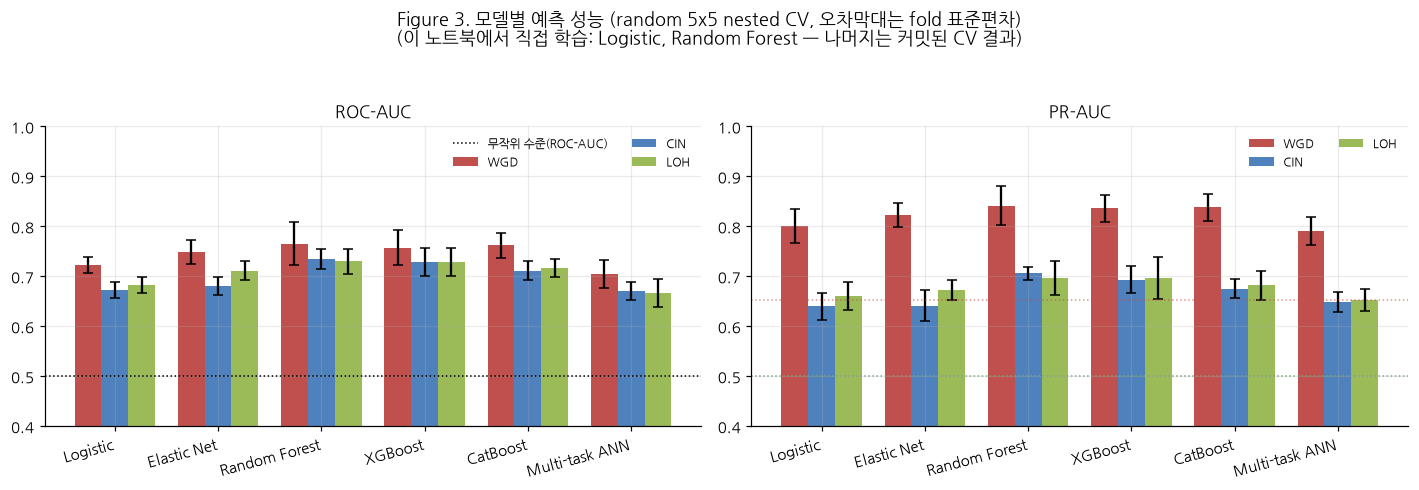

[이 노트북에서 학습한 모델의 평균 ROC-AUC]
target  model        
cin     logistic         0.672
        random_forest    0.734
loh     logistic         0.683
        random_forest    0.730
wgd     logistic         0.723
        random_forest    0.765


In [7]:
# Figure 3 — 위 셀에서 방금 학습한 결과(cv_live)로 그린다.
# RUN_MODELS 에 없는 모델은 저장소에 커밋된 results/tables/cv_random_*.csv 로 채운다.
MODEL_ORDER = ["logistic", "elastic_net", "random_forest", "xgboost", "catboost", "multitask_ann"]
MODEL_LABEL = {"logistic": "Logistic", "elastic_net": "Elastic Net",
               "random_forest": "Random Forest", "xgboost": "XGBoost",
               "catboost": "CatBoost", "multitask_ann": "Multi-task ANN"}

frames = [cv_live]
for m in MODEL_ORDER:
    if m in RUN_MODELS:
        continue
    for t in TARGETS:
        # glob 대신 정확한 파일명만 읽는다 — cv_random_random_forest_damaging_only_wgd.csv
        # (보조 파일)까지 섞이면 WGD/RF 행이 오염된다.
        path = TABLES / f"cv_random_{m}_{t}.csv"
        if path.exists():
            frames.append(pd.read_csv(path))
cv = pd.concat(frames, ignore_index=True)

# PR-AUC 의 무작위 기준선은 0.5 가 아니라 표현형별 양성 비율이다.
prevalence = {"wgd": float(cohort_y.wgd.mean())}
for t in ("cin", "loh"):
    prevalence[t] = float((cohort_y[t] >= cohort_y[t].median()).mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
models = [m for m in MODEL_ORDER if m in set(cv.model)]
width, x = 0.26, np.arange(len(models))

for ax, metric, title in ((axes[0], "roc_auc", "ROC-AUC"), (axes[1], "pr_auc", "PR-AUC")):
    for i, target in enumerate(TARGETS):
        sub = cv[cv.target == target]
        means = [sub[sub.model == m][metric].mean() for m in models]
        errs = [sub[sub.model == m][metric].std() for m in models]
        ax.bar(x + (i - 1) * width, means, width, yerr=errs, capsize=3,
               label=TARGET_LABEL[target], color=PHENOTYPE_COLORS[target])
    if metric == "roc_auc":
        ax.axhline(0.5, color="k", ls=":", lw=1, label="무작위 수준(ROC-AUC)")
    else:
        for target in TARGETS:
            ax.axhline(prevalence[target], color=PHENOTYPE_COLORS[target], ls=":", lw=1, alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABEL[m] for m in models], rotation=15, ha="right")
    ax.set_title(title)
    ax.set_ylim(0.4, 1.0)
    ax.legend(fontsize=8, ncol=2)

live = ", ".join(MODEL_LABEL[m] for m in RUN_MODELS)
fig.suptitle("Figure 3. 모델별 예측 성능 (random 5x5 nested CV, 오차막대는 fold 표준편차)\n"
             f"(이 노트북에서 직접 학습: {live} — 나머지는 커밋된 CV 결과)",
             y=1.05, fontsize=12)
fig.tight_layout()
plt.show()

print("[이 노트북에서 학습한 모델의 평균 ROC-AUC]")
print(cv_live.groupby(["target", "model"]).roc_auc.mean().round(3).to_string())

## 3. Random Forest Confusion Matrix

5개 outer fold의 test 예측을 pooled 한 confusion matrix.

§3-1 에서 학습한 Random Forest 의 outer fold 예측을 pool 했다 (추가 학습 없음).


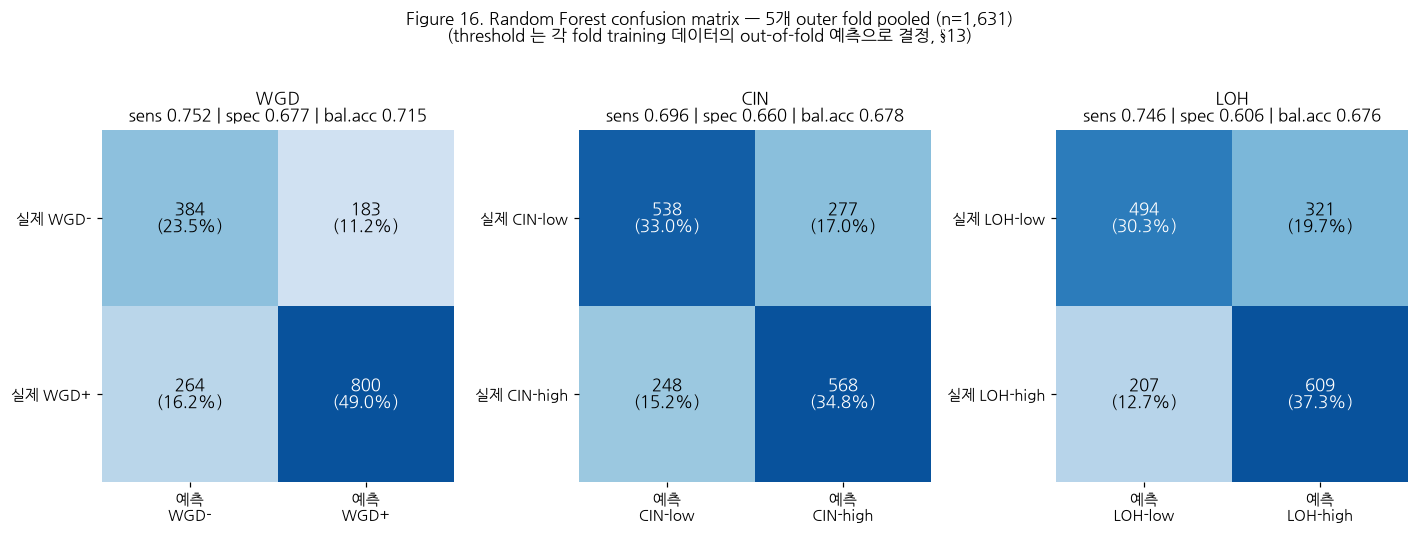

In [8]:
# Figure 16 — §3-1 학습이 남긴 outer test 예측을 모아서(pool) 만든다.
# 예전에는 여기서 Random Forest 를 다시 학습했는데(표현형당 130회 적합),
# §3-1 과 완전히 같은 계산이라 중복이었다. run_nested_cv 가 예측을 돌려주므로
# 이제 추가 학습이 없다.
from sklearn.metrics import confusion_matrix

CLASS_LABEL = {"wgd": ("WGD-", "WGD+"), "cin": ("CIN-low", "CIN-high"),
               "loh": ("LOH-low", "LOH-high")}

if ("random_forest", "wgd") in live_predictions:
    cm_rows = []
    for _t in TARGETS:
        p = live_predictions[("random_forest", _t)]
        tn, fp, fn, tp = confusion_matrix(p.y_true, p.y_pred, labels=[0, 1]).ravel()
        sens, spec_ = tp / (tp + fn), tn / (tn + fp)
        cm_rows.append({"target": _t, "tn": tn, "fp": fp, "fn": fn, "tp": tp,
                        "n": len(p), "sensitivity": sens, "specificity": spec_,
                        "balanced_accuracy": (sens + spec_) / 2})
    cm_df = pd.DataFrame(cm_rows).set_index("target")
    print("§3-1 에서 학습한 Random Forest 의 outer fold 예측을 pool 했다 (추가 학습 없음).")
else:
    cm_df = pd.read_csv(TABLES / "day33_rf_confusion_matrix.csv").set_index("target")
    print("RUN_MODELS 에 random_forest 가 없어 커밋된 결과를 사용한다.")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
for ax, target in zip(axes, TARGETS):
    row = cm_df.loc[target]
    cm = np.array([[row.tn, row.fp], [row.fn, row.tp]])
    cm_pct = cm / cm.sum() * 100
    ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=cm_pct.max() * 1.15)
    labels = CLASS_LABEL[target]
    for i in range(2):
        for j in range(2):
            color = "white" if cm_pct[i, j] > cm_pct.max() * 0.6 else "black"
            ax.text(j, i, f"{int(cm[i, j])}\n({cm_pct[i, j]:.1f}%)",
                    ha="center", va="center", fontsize=11, color=color)
    ax.set_xticks([0, 1]); ax.set_xticklabels([f"예측\n{labels[0]}", f"예측\n{labels[1]}"])
    ax.set_yticks([0, 1]); ax.set_yticklabels([f"실제 {labels[0]}", f"실제 {labels[1]}"])
    ax.set_title(f"{TARGET_LABEL[target]}\nsens {row.sensitivity:.3f} | "
                 f"spec {row.specificity:.3f} | bal.acc {row.balanced_accuracy:.3f}")
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.grid(False)

fig.suptitle("Figure 16. Random Forest confusion matrix — 5개 outer fold pooled (n=1,631)\n"
             "(threshold 는 각 fold training 데이터의 out-of-fold 예측으로 결정, §13)",
             y=1.06, fontsize=11)
fig.tight_layout()
plt.show()

## 4. Feature Importance — 어떤 mutation이 중요한가

각 outer fold의 training data에서 feature selection을 반복해, 5개 fold
전부에서 선택된("전 fold 공통") 유전자를 찾는다(Random Forest 기준).

In [9]:
for target in ("wgd", "cin", "loh"):
    df = pd.read_csv(TABLES / f"day11_selection_random_forest_{target}.csv")
    common = df[df.selection_freq == 1.0]
    genes = ", ".join(common.gene.head(8))
    print(f"{target.upper()}: 전 fold(5/5) 공통 {len(common)}개 — {genes}")

WGD: 전 fold(5/5) 공통 19개 — TP53, TP53, TERT, BRAF, ID3, LRP1B, TTN, KRAS
CIN: 전 fold(5/5) 공통 21개 — TP53, TP53, TERT, RB1, ID3, BRAF, PIK3CA, KRAS
LOH: 전 fold(5/5) 공통 18개 — TP53, TP53, RB1, ID3, KRAS, NF2, ARID1A, PITX1


§3-1 학습에서 fold 별로 기록한 중요도를 집계했다.


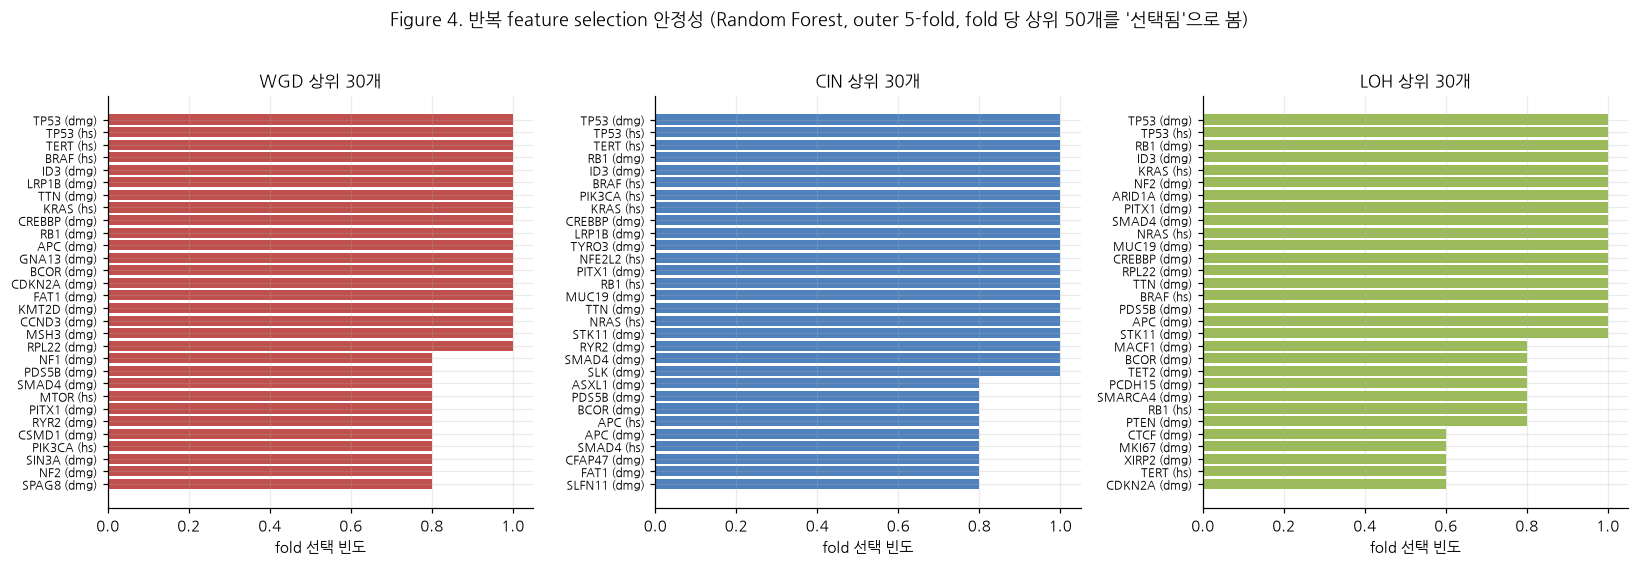

  WGD: 전 fold 선택 19개 — TP53 (dmg), TP53 (hs), TERT (hs), BRAF (hs), ID3 (dmg), LRP1B (dmg), TTN (dmg), KRAS (hs)
  CIN: 전 fold 선택 21개 — TP53 (dmg), TP53 (hs), TERT (hs), RB1 (dmg), ID3 (dmg), BRAF (hs), PIK3CA (hs), KRAS (hs)
  LOH: 전 fold 선택 18개 — TP53 (dmg), TP53 (hs), RB1 (dmg), ID3 (dmg), KRAS (hs), NF2 (dmg), ARID1A (dmg), PITX1 (dmg)


In [10]:
# Figure 4 — §3-1 학습이 fold 마다 기록한 중요도를 src 의 aggregate_selection 으로 집계한다.
TOP_N, TOP_K = 30, 50


def short(feature, width=22):
    """'TP53 (7157)_damaging' -> 'TP53 (dmg)'"""
    gene = feature.split(" (")[0]
    kind = "hs" if feature.endswith("_hotspot") else "dmg"
    return f"{gene} ({kind})"[:width]


_key = ("random_forest", "wgd")
if _key in live_importances and not live_importances[_key].empty:
    aggs = {t: aggregate_selection(live_importances[("random_forest", t)], top_k=TOP_K)
            for t in TARGETS}
    print("§3-1 학습에서 fold 별로 기록한 중요도를 집계했다.")
else:
    aggs = {t: pd.read_csv(TABLES / f"day11_selection_random_forest_{t}.csv") for t in TARGETS}
    print("RUN_MODELS 에 random_forest 가 없어 커밋된 결과를 사용한다.")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, target in zip(axes, TARGETS):
    top = aggs[target].head(TOP_N).iloc[::-1]
    ax.barh([short(f) for f in top.feature], top.selection_freq, color=PHENOTYPE_COLORS[target])
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("fold 선택 빈도")
    ax.set_title(f"{TARGET_LABEL[target]} 상위 {TOP_N}개")
    ax.tick_params(axis="y", labelsize=8)

fig.suptitle(f"Figure 4. 반복 feature selection 안정성 (Random Forest, outer 5-fold, "
             f"fold 당 상위 {TOP_K}개를 '선택됨'으로 봄)", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

for t in TARGETS:
    stable = aggs[t][aggs[t].selection_freq == 1.0]
    print(f"  {TARGET_LABEL[t]}: 전 fold 선택 {len(stable)}개 — "
          + ", ".join(short(f) for f in stable.feature.head(8)))

**TP53이 세 표현형 모두에서 압도적 1위**(평균 순위 1.0, 순위 표준편차 0)다.
ID3·BRAF·CREBBP도 세 표현형 공통 후보로 반복 선택된다.

## 5. 최소 Mutation Panel

10개 mutation으로 전체 성능의 93\~99%가 유지된다.

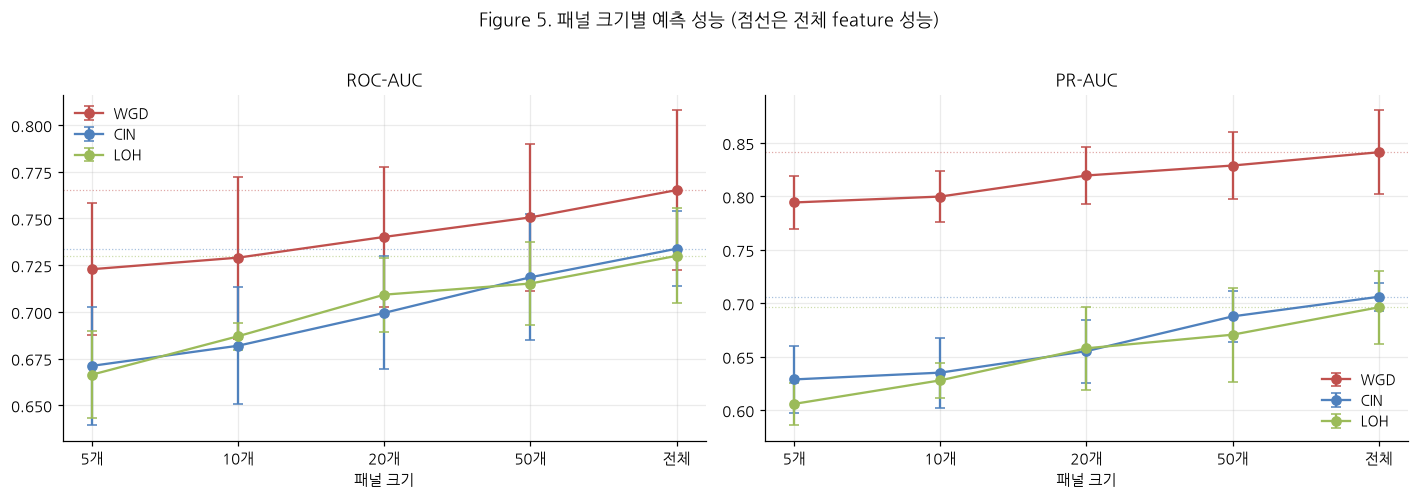

In [11]:
# Figure 5 — scripts/08_panel_curve.py 의 plot_curve() 를 그대로 옮긴 것.
metrics = pd.read_csv(TABLES / "day12_panel_metrics_random_forest.csv")
metrics["panel_size"] = metrics["panel_size"].astype(str)
sizes = sorted({int(s) for s in metrics.panel_size.unique() if s != "all"})
order = [str(s) for s in sizes] + ["all"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, metric, title in ((axes[0], "roc_auc", "ROC-AUC"), (axes[1], "pr_auc", "PR-AUC")):
    for target in TARGETS:
        sub = metrics[metrics.target == target]
        g = sub.groupby("panel_size")[metric]
        mean, std = g.mean().reindex(order), g.std().reindex(order)
        ax.errorbar(range(len(order)), mean, yerr=std, marker="o", capsize=3,
                    label=TARGET_LABEL[target], color=PHENOTYPE_COLORS[target])
        full = mean.get("all")
        if pd.notna(full):
            ax.axhline(full, color=PHENOTYPE_COLORS[target], ls=":", lw=0.8, alpha=0.5)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([f"{o}개" if o != "all" else "전체" for o in order])
    ax.set_xlabel("패널 크기")
    ax.set_title(title)
    ax.legend(fontsize=9)

fig.suptitle("Figure 5. 패널 크기별 예측 성능 (점선은 전체 feature 성능)", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

## 6. 후속 실험 — Pathway(음성) vs Signature(양성) vs 결합(항상 개선)

Pathway 재집계 — 6/6 조합 전부 하락 (음성)


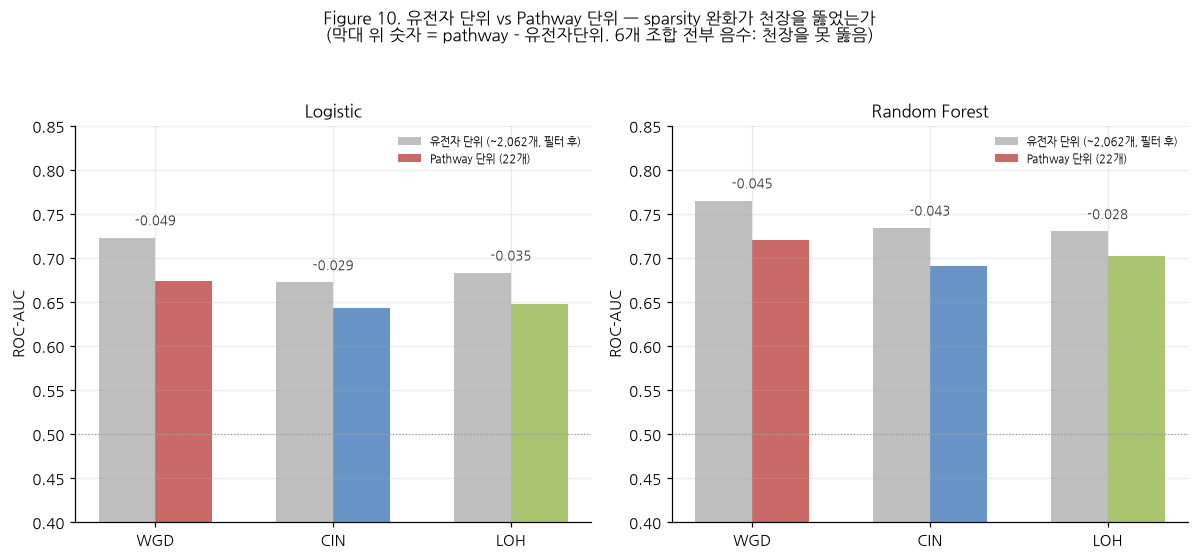

target         model  gene_level_auc  pathway_auc     차이
   wgd      logistic           0.723        0.674 -0.049
   cin      logistic           0.672        0.643 -0.029
   loh      logistic           0.683        0.648 -0.035
   wgd random_forest           0.765        0.720 -0.045
   cin random_forest           0.734        0.691 -0.043
   loh random_forest           0.730        0.702 -0.028
Mutation signature(96-class) — 5/6 조합 개선 (양성)


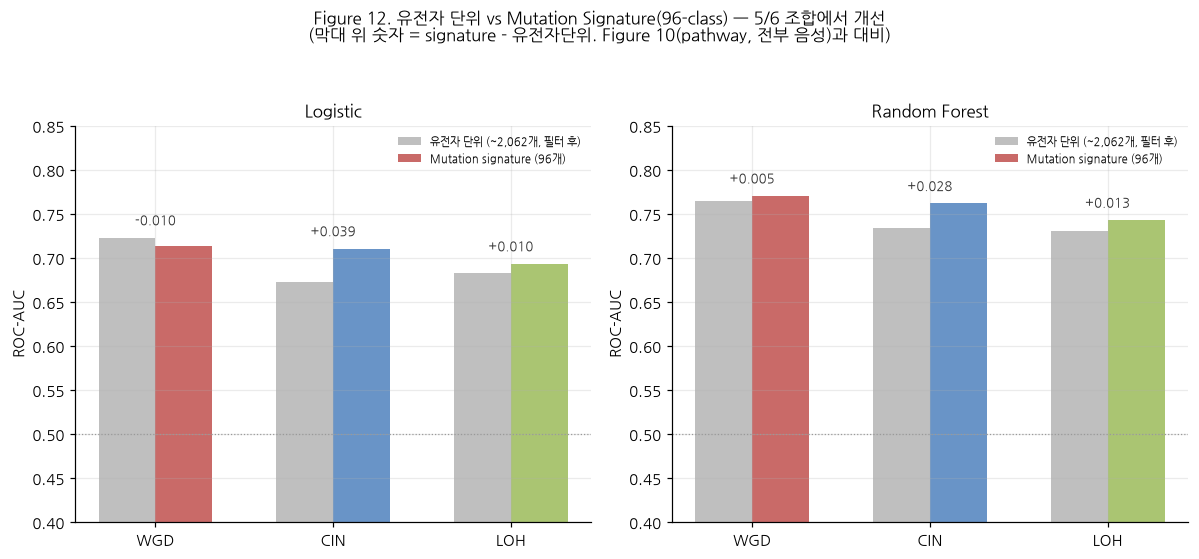

target         model  gene_level_auc  signature_auc     차이
   wgd      logistic           0.723          0.713 -0.010
   cin      logistic           0.672          0.711  0.039
   loh      logistic           0.683          0.693  0.010
   wgd random_forest           0.765          0.770  0.005
   cin random_forest           0.734          0.762  0.028
   loh random_forest           0.730          0.743  0.013
유전자+Signature 결합 — 6/6 조합 전부 개선


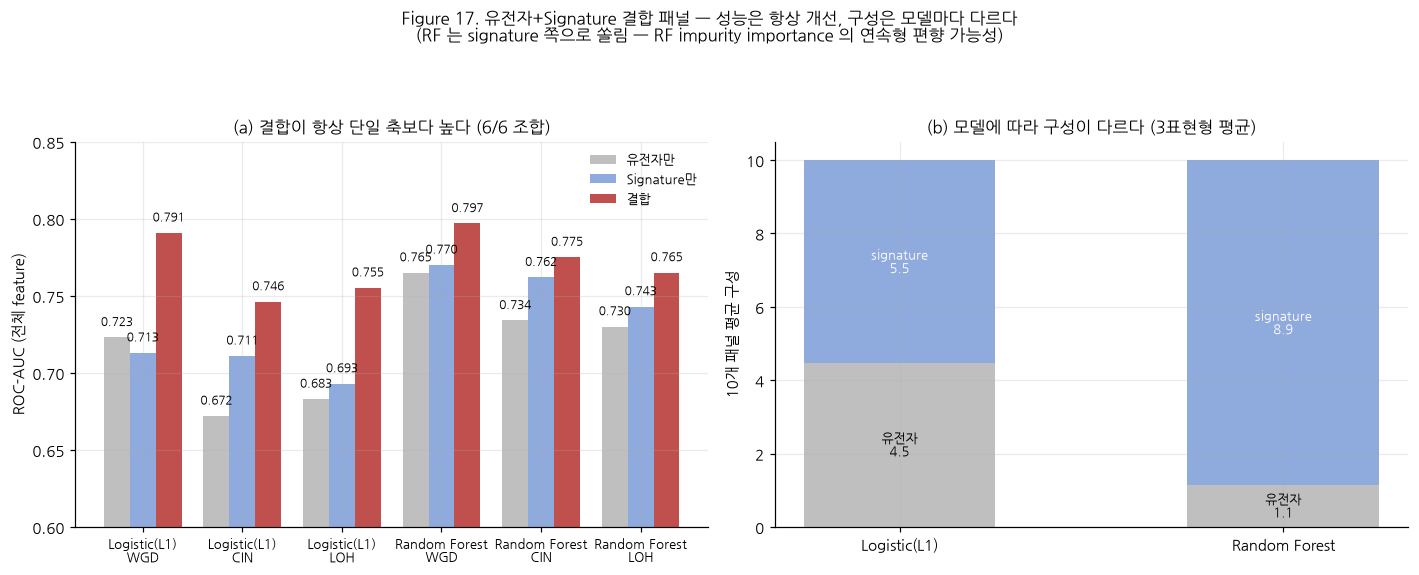

In [12]:
print("Pathway 재집계 — 6/6 조합 전부 하락 (음성)")
# Figure 10 — scripts 의 해당 plot 스크립트를 그대로 옮긴 것.
df = pd.read_csv(TABLES / "day19_pathway_vs_gene.csv")
models = ["logistic", "random_forest"]
MODEL_LABEL2 = {"logistic": "Logistic", "random_forest": "Random Forest"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, model in zip(axes, models):
    sub = df[df.model == model].set_index("target").reindex(list(TARGETS))
    x, width = np.arange(3), 0.32
    ax.bar(x - width / 2, sub.gene_level_auc, width,
           label="유전자 단위 (~2,062개, 필터 후)", color="#bfbfbf")
    ax.bar(x + width / 2, sub.pathway_auc, width,
           label="Pathway 단위 (22개)", color=[PHENOTYPE_COLORS[t] for t in TARGETS], alpha=0.85)
    for i, (gene_auc, other) in enumerate(zip(sub.gene_level_auc, sub.pathway_auc)):
        ax.text(i, max(gene_auc, other) + 0.015, f"{other - gene_auc:+.3f}",
                ha="center", fontsize=8.5, color="#333")
    ax.axhline(0.5, color="#999", ls=":", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([TARGET_LABEL[t] for t in TARGETS])
    ax.set_ylim(0.4, 0.85)
    ax.set_ylabel("ROC-AUC")
    ax.set_title(MODEL_LABEL2[model])
    ax.legend(fontsize=7.5, loc="upper right")

fig.suptitle("Figure 10. 유전자 단위 vs Pathway 단위 — sparsity 완화가 천장을 뚫었는가\n"
             "(막대 위 숫자 = pathway - 유전자단위. 6개 조합 전부 음수: 천장을 못 뚫음)", y=1.05, fontsize=11)
fig.tight_layout()
plt.show()
print(df.round(3).to_string(index=False))

print("Mutation signature(96-class) — 5/6 조합 개선 (양성)")
# Figure 12 — scripts 의 해당 plot 스크립트를 그대로 옮긴 것.
df = pd.read_csv(TABLES / "day24_signature_vs_gene.csv")
models = ["logistic", "random_forest"]
MODEL_LABEL2 = {"logistic": "Logistic", "random_forest": "Random Forest"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, model in zip(axes, models):
    sub = df[df.model == model].set_index("target").reindex(list(TARGETS))
    x, width = np.arange(3), 0.32
    ax.bar(x - width / 2, sub.gene_level_auc, width,
           label="유전자 단위 (~2,062개, 필터 후)", color="#bfbfbf")
    ax.bar(x + width / 2, sub.signature_auc, width,
           label="Mutation signature (96개)", color=[PHENOTYPE_COLORS[t] for t in TARGETS], alpha=0.85)
    for i, (gene_auc, other) in enumerate(zip(sub.gene_level_auc, sub.signature_auc)):
        ax.text(i, max(gene_auc, other) + 0.015, f"{other - gene_auc:+.3f}",
                ha="center", fontsize=8.5, color="#333")
    ax.axhline(0.5, color="#999", ls=":", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([TARGET_LABEL[t] for t in TARGETS])
    ax.set_ylim(0.4, 0.85)
    ax.set_ylabel("ROC-AUC")
    ax.set_title(MODEL_LABEL2[model])
    ax.legend(fontsize=7.5, loc="upper right")

fig.suptitle("Figure 12. 유전자 단위 vs Mutation Signature(96-class) — 5/6 조합에서 개선\n"
             "(막대 위 숫자 = signature - 유전자단위. Figure 10(pathway, 전부 음성)과 대비)", y=1.05, fontsize=11)
fig.tight_layout()
plt.show()
print(df.round(3).to_string(index=False))

print("유전자+Signature 결합 — 6/6 조합 전부 개선")
# Figure 17 — scripts/35_plot_combined_panel.py 를 그대로 옮긴 것.
summary = pd.read_csv(TABLES / "day32_combined_vs_single_summary.csv")
comp = pd.read_csv(TABLES / "day32_combined_panel_composition.csv")
CMODELS = ("logistic_l1", "random_forest")
CMODEL_LABEL = {"logistic_l1": "Logistic(L1)", "random_forest": "Random Forest"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ax = axes[0]
combos = [(m, t) for m in CMODELS for t in TARGETS]
x, width = np.arange(len(combos)), 0.26
pick = lambda col: [summary[(summary.model == m) & (summary.target == t)][col].iloc[0]
                    for m, t in combos]
gene_v, sig_v, combined_v = pick("유전자만"), pick("signature만"), pick("결합")

ax.bar(x - width, gene_v, width, label="유전자만", color="#bfbfbf")
ax.bar(x, sig_v, width, label="Signature만", color="#8faadc")
ax.bar(x + width, combined_v, width, label="결합", color="#c0504d")
for i, v in enumerate(gene_v):
    ax.text(i - width, v + 0.008, f"{v:.3f}", ha="center", fontsize=8)
for i, v in enumerate(sig_v):
    ax.text(i, v + 0.008, f"{v:.3f}", ha="center", fontsize=8)
for i, v in enumerate(combined_v):
    ax.text(i + width, v + 0.008, f"{v:.3f}", ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([f"{CMODEL_LABEL[m]}\n{TARGET_LABEL[t]}" for m, t in combos], fontsize=8.5)
ax.set_ylabel("ROC-AUC (전체 feature)")
ax.set_ylim(0.6, 0.85)
ax.set_title("(a) 결합이 항상 단일 축보다 높다 (6/6 조합)")
ax.legend(fontsize=8.5)

ax2 = axes[1]
comp10 = comp[comp.panel_size == 10].groupby("model")[["n_genes", "n_sig"]].mean().reindex(CMODELS)
xm = np.arange(len(CMODELS))
ax2.bar(xm, comp10.n_genes, 0.5, label="유전자", color="#bfbfbf")
ax2.bar(xm, comp10.n_sig, 0.5, bottom=comp10.n_genes, label="Signature class", color="#8faadc")
for i, (g, s) in enumerate(zip(comp10.n_genes, comp10.n_sig)):
    ax2.text(i, g / 2, f"유전자\n{g:.1f}", ha="center", va="center", fontsize=8.5)
    ax2.text(i, g + s / 2, f"signature\n{s:.1f}", ha="center", va="center", fontsize=8.5, color="white")
ax2.set_xticks(list(xm))
ax2.set_xticklabels([CMODEL_LABEL[m] for m in CMODELS])
ax2.set_ylabel("10개 패널 평균 구성")
ax2.set_title("(b) 모델에 따라 구성이 다르다 (3표현형 평균)")

fig.suptitle("Figure 17. 유전자+Signature 결합 패널 — 성능은 항상 개선, 구성은 모델마다 다르다\n"
             "(RF 는 signature 쪽으로 쏠림 — RF impurity importance 의 연속형 편향 가능성)",
             y=1.08, fontsize=11)
fig.tight_layout()
plt.show()

## 7. TCGA 외부 코호트 검증

세포주가 아닌 실제 환자 종양(TCGA)에서 WGD를 검증 — 내부 0.762 → 외부 0.594
(방법론적 한계로 인한 하한 추정치, 상세는 전체 노트북 §13 참고).

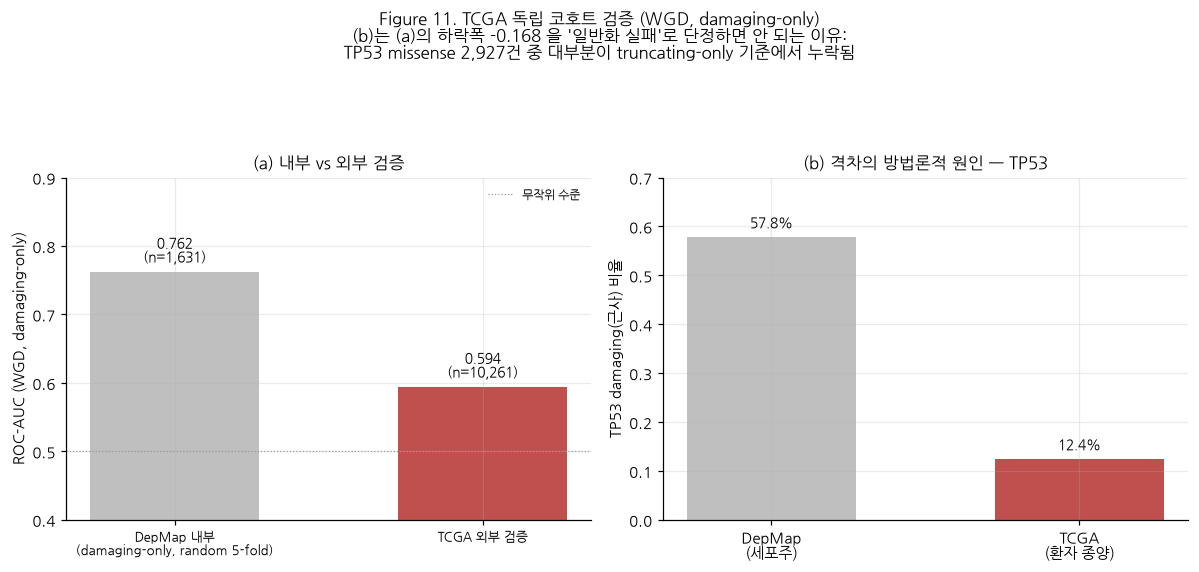

                                  stage  roc_auc     n
DepMap 내부(damaging-only, random 5-fold) 0.762229  1631
                             TCGA 외부 검증 0.594063 10261


In [13]:
# Figure 11 — scripts/22_plot_tcga_validation.py 를 그대로 옮긴 것.
tcga = pd.read_csv(TABLES / "day21_tcga_validation_summary.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
ax = axes[0]
bars = ax.bar(tcga.stage.str.replace("(", "\n(", regex=False), tcga.roc_auc,
              color=["#bfbfbf", PHENOTYPE_COLORS["wgd"]], width=0.55)
for b, v, n in zip(bars, tcga.roc_auc, tcga.n):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.3f}\n(n={n:,})",
            ha="center", fontsize=9)
ax.axhline(0.5, color="#999", ls=":", lw=0.8, label="무작위 수준")
ax.set_ylim(0.4, 0.9)
ax.set_ylabel("ROC-AUC (WGD, damaging-only)")
ax.set_title("(a) 내부 vs 외부 검증")
ax.legend(fontsize=8)
ax.tick_params(axis="x", labelsize=8.5)

ax = axes[1]
tp53 = pd.DataFrame({"cohort": ["DepMap\n(세포주)", "TCGA\n(환자 종양)"], "rate": [0.578, 0.124]})
ax.bar(tp53.cohort, tp53.rate, color=["#bfbfbf", PHENOTYPE_COLORS["wgd"]], width=0.55)
for i, v in enumerate(tp53.rate):
    ax.text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=9)
ax.set_ylim(0, 0.7)
ax.set_ylabel("TP53 damaging(근사) 비율")
ax.set_title("(b) 격차의 방법론적 원인 — TP53")

fig.suptitle("Figure 11. TCGA 독립 코호트 검증 (WGD, damaging-only)\n"
             "(b)는 (a)의 하락폭 -0.168 을 '일반화 실패'로 단정하면 안 되는 이유:\n"
             "TP53 missense 2,927건 중 대부분이 truncating-only 기준에서 누락됨",
             y=1.12, fontsize=11)
fig.tight_layout()
plt.show()
print(tcga.to_string(index=False))

## 8. 탐색적 분석 — 연관성 검정 / 암종별 UMAP

팀원(psh03)이 만든 탐색 시각화를 파이프라인 규약에 맞춰 옮긴 것
(`scripts/42`\~`48`). nested CV 성능 추정치를 대체하지 않는 **탐색적** 분석이다.

빈도 필터 통과 feature: 617개 (prevalence >= 1.0%)


[WGD] FDR < 0.05: 28개 / 617개 (상위: TP53 (7157)_damaging, q=7.05e-38)


[CIN] FDR < 0.05: 62개 / 617개 (상위: TP53 (7157)_damaging, q=1.39e-26)


[LOH] FDR < 0.05: 110개 / 617개 (상위: TP53 (7157)_damaging, q=1.13e-30)


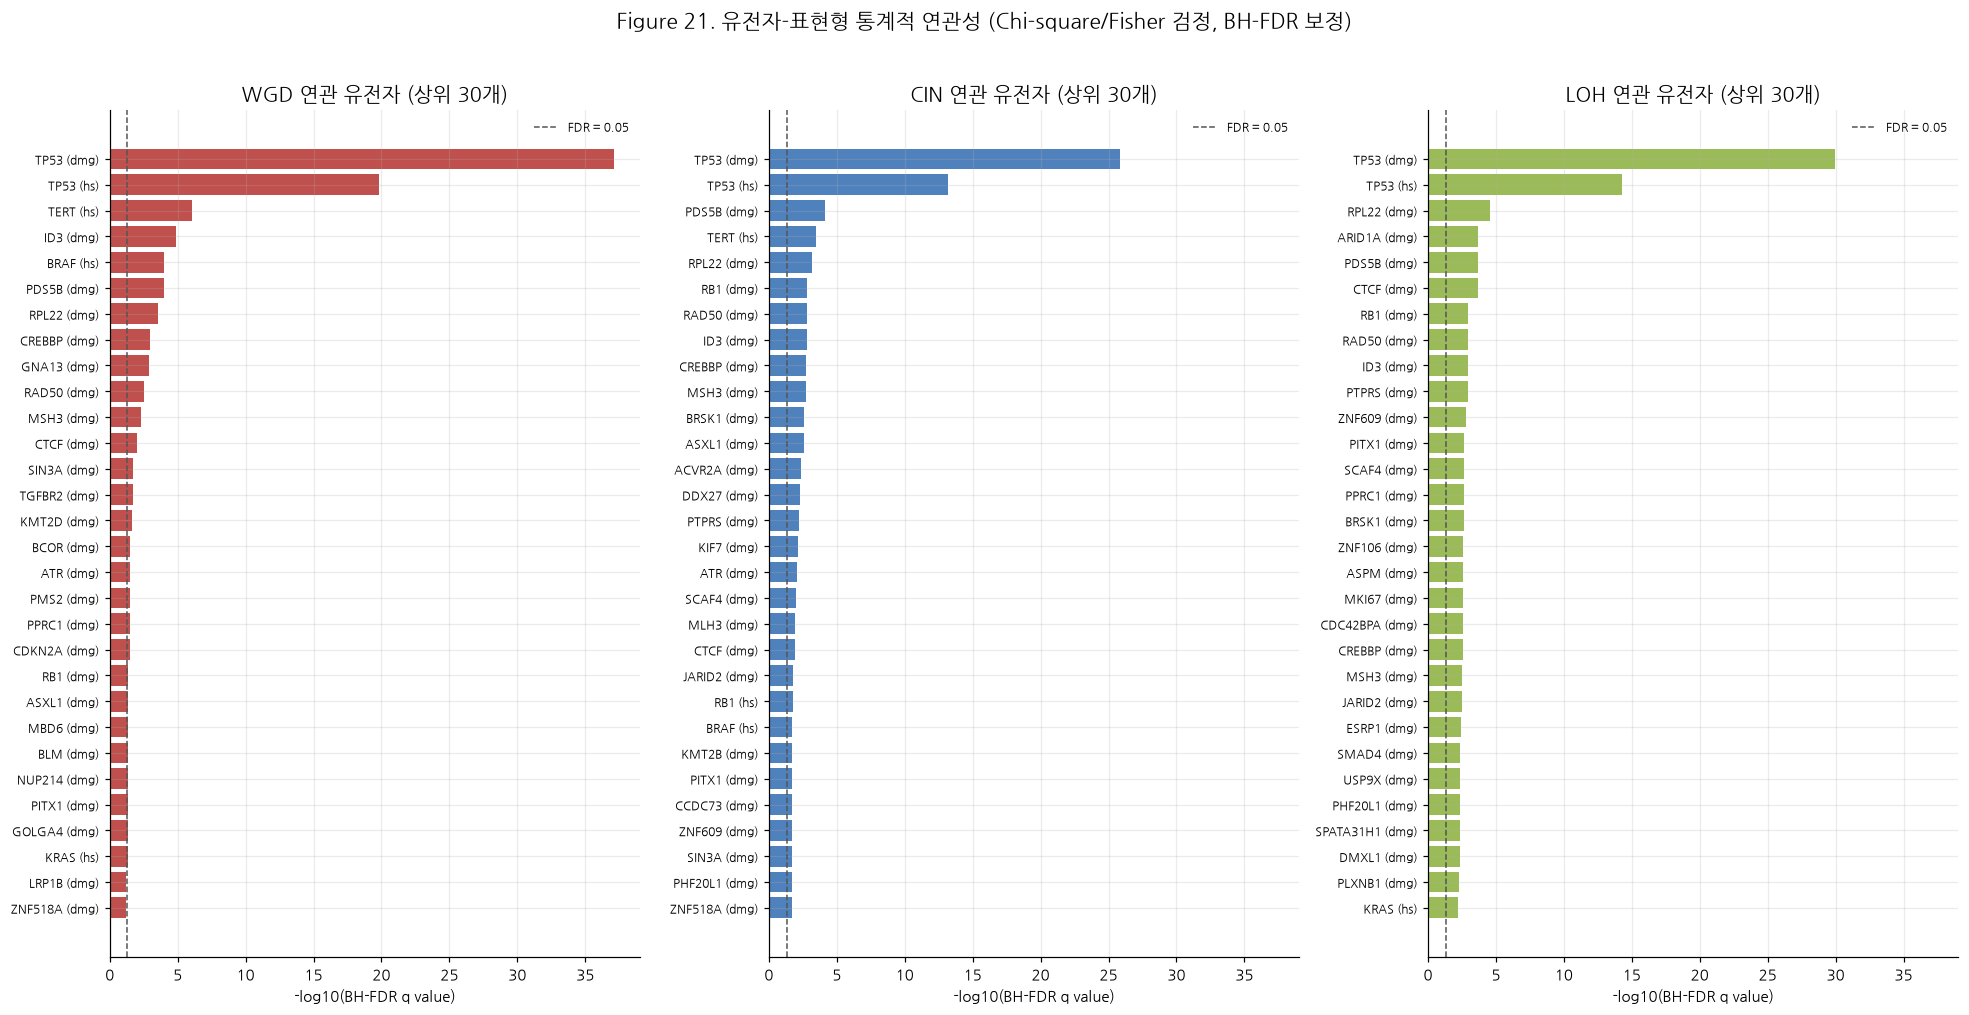

In [14]:
# Figure 21/22 — scripts/42_mutation_association.py + 43_plot_mutation_association.py
# 여기서 chi-square/Fisher 검정을 실제로 수행한다 (CSV 를 읽어오지 않는다).
import re

from scipy.stats import chi2_contingency, fisher_exact

MIN_PREVALENCE = 0.01   # mutation 빈도 1% 미만 feature 제외 (outcome 과 무관한 필터)


def bh_fdr(p_values: pd.Series) -> pd.Series:
    """Benjamini-Hochberg FDR q-value (statsmodels 의존성 없이)."""
    p = p_values.to_numpy(dtype=float)
    order = np.argsort(p)
    ranked = p[order] * len(p) / np.arange(1, len(p) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    q = np.empty_like(ranked)
    q[order] = np.minimum(ranked, 1.0)
    return pd.Series(q, index=p_values.index)


# WGD 는 원래 binary, CIN/LOH 는 전체 코호트 중앙값으로 탐색용 이진화
labels_bin = pd.DataFrame(index=cohort_y.index)
labels_bin["wgd"] = cohort_y["wgd"].astype(int)
for _t in ("cin", "loh"):
    labels_bin[_t] = (cohort_y[_t] >= cohort_y[_t].median()).astype(int)

_prev = cohort_X.mean(axis=0)
X_assoc = cohort_X.loc[:, _prev[_prev >= MIN_PREVALENCE].sort_values(ascending=False).index]
print(f"빈도 필터 통과 feature: {X_assoc.shape[1]}개 (prevalence >= {MIN_PREVALENCE:.1%})")


def association_tests(X, labels, target):
    """feature × binary phenotype 의 Fisher/chi-square, OR 와 95% CI, BH-FDR."""
    outcome = labels[target].to_numpy()
    rows = []
    for feature in X.columns:
        mut = X[feature].to_numpy().astype(int)
        a = int(((mut == 1) & (outcome == 1)).sum())
        b = int(((mut == 1) & (outcome == 0)).sum())
        c = int(((mut == 0) & (outcome == 1)).sum())
        d = int(((mut == 0) & (outcome == 0)).sum())
        table = np.array([[a, b], [c, d]])
        if (chi2_contingency(table, correction=False).expected_freq < 5).any():
            odds_ratio, p_value = fisher_exact(table)
            test = "Fisher exact"
        else:
            _, p_value, _, _ = chi2_contingency(table, correction=False)
            odds_ratio = (a * d) / (b * c) if b and c else np.inf
            test = "Chi-square"
        # 0 cell 에서 OR/CI 가 무한대가 되지 않도록 Haldane-Anscombe 보정
        aa, bb, cc, dd = np.array([a, b, c, d], dtype=float) + 0.5
        log_or = np.log((aa * dd) / (bb * cc))
        se = np.sqrt(1 / aa + 1 / bb + 1 / cc + 1 / dd)
        rows.append({"feature": feature, "test": test, "odds_ratio": odds_ratio,
                     "odds_ratio_ci_low": np.exp(log_or - 1.96 * se),
                     "odds_ratio_ci_high": np.exp(log_or + 1.96 * se), "p_value": p_value})
    out = pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)
    out["fdr_q_value"] = bh_fdr(out["p_value"])
    return out


assoc = {}
for _t in TARGETS:
    assoc[_t] = association_tests(X_assoc, labels_bin, _t)
    _n = int((assoc[_t].fdr_q_value < 0.05).sum())
    print(f"[{TARGET_LABEL[_t]}] FDR < 0.05: {_n}개 / {len(assoc[_t])}개 "
          f"(상위: {assoc[_t].iloc[0].feature}, q={assoc[_t].iloc[0].fdr_q_value:.2e})")


def shorten_feature(name: str) -> str:
    name = re.sub(r"\s*\(\d+\)", "", name)
    return name.replace("_damaging", " (dmg)").replace("_hotspot", " (hs)")


# --- Figure 21. 표현형별 상위 30개 연관 유전자 ---
tops, max_val = {}, 0.0
for _t in TARGETS:
    top30 = assoc[_t].head(30).copy().sort_values("fdr_q_value", ascending=False)
    top30["minus_log10_fdr"] = -np.log10(top30.fdr_q_value.clip(lower=1e-300))
    top30["short_feature"] = top30.feature.map(shorten_feature)
    tops[_t] = top30
    max_val = max(max_val, top30.minus_log10_fdr.max())

fig, axes = plt.subplots(1, 3, figsize=(18, 9))
for ax, _t in zip(axes, TARGETS):
    top30 = tops[_t]
    ax.barh(top30.short_feature, top30.minus_log10_fdr, color=PHENOTYPE_COLORS[_t])
    ax.axvline(-np.log10(0.05), color="#555", ls="--", lw=1, label="FDR = 0.05")
    ax.set_title(f"{TARGET_LABEL[_t]} 연관 유전자 (상위 30개)", fontsize=13)
    ax.set_xlabel("-log10(BH-FDR q value)")
    ax.set_xlim(0, max_val * 1.05)
    ax.tick_params(axis="y", labelsize=8)
    ax.legend(fontsize=8)
fig.suptitle("Figure 21. 유전자-표현형 통계적 연관성 (Chi-square/Fisher 검정, BH-FDR 보정)",
             y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

/home/kali/adni-shared/AI-bio-proj-team-1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


UMAP 직접 계산 완료 — feature 80개, 세포주 1,631개


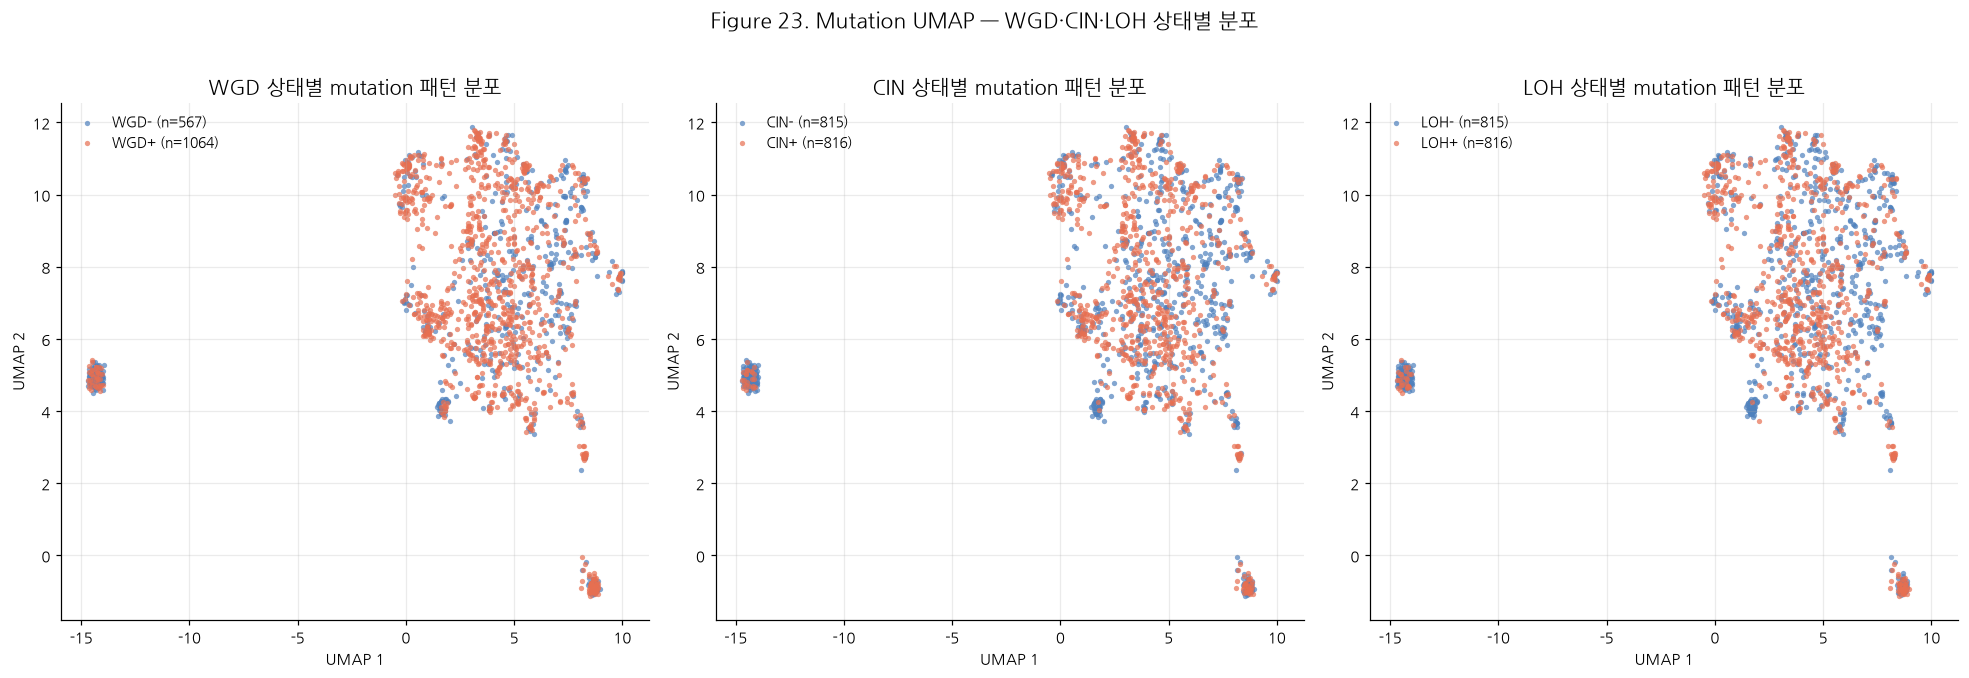

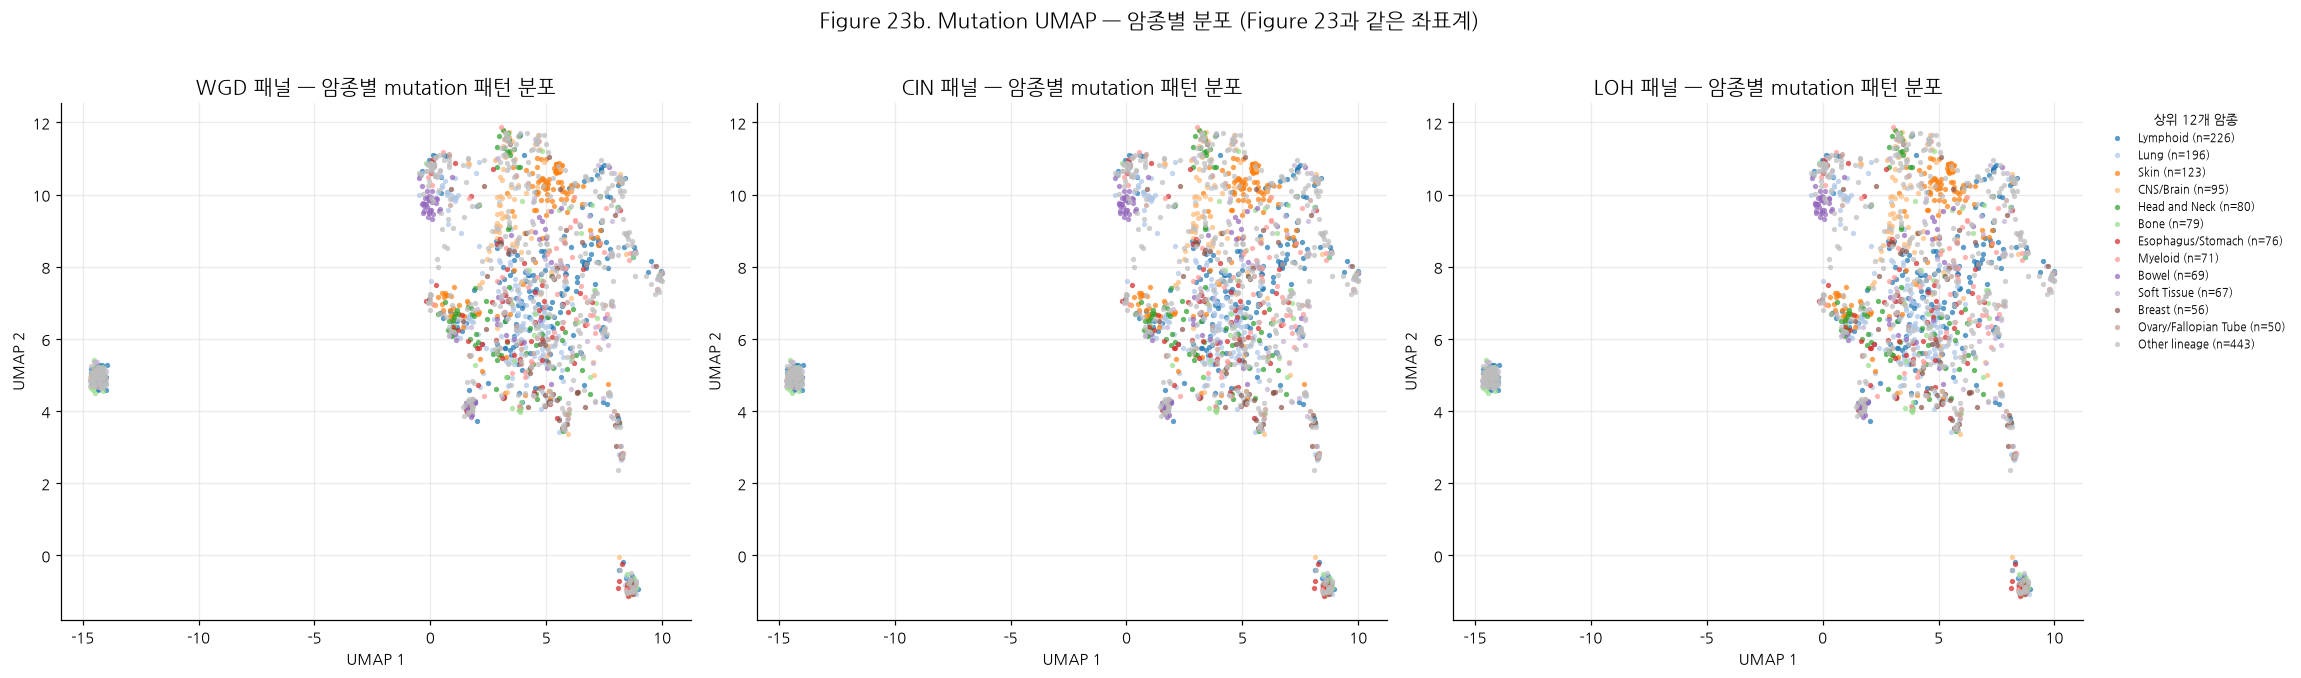

In [15]:
# Figure 23 / 23b — scripts/44_mutation_umap.py + 45_plot_mutation_umap.py
# UMAP 좌표를 여기서 직접 계산한다. umap-learn 이 없으면 커밋된 좌표 CSV 로 대체.
UMAP_FEATURES = 80
TOP_N_LINEAGES = 12

_keep = _prev[_prev >= MIN_PREVALENCE].sort_values(ascending=False)
X_umap = cohort_X.loc[:, _keep.index[:UMAP_FEATURES]]

try:
    import umap.umap_ as umap
    import warnings as _w
    with _w.catch_warnings():
        _w.simplefilter("ignore")
        _reducer = umap.UMAP(n_neighbors=20, min_dist=0.25, metric="jaccard", random_state=SEED)
        _xy = _reducer.fit_transform(X_umap.to_numpy(dtype=bool))
    umap_df = pd.DataFrame({"UMAP1": _xy[:, 0], "UMAP2": _xy[:, 1]}, index=cohort_X.index)
    for _t in TARGETS:
        umap_df[_t] = labels_bin[_t].values
    umap_df["lineage"] = cohort_groups.reindex(cohort_X.index).values
    print(f"UMAP 직접 계산 완료 — feature {X_umap.shape[1]}개, 세포주 {len(umap_df):,}개")
except ImportError:
    umap_df = pd.read_csv(TABLES / "day44_mutation_umap_coords.csv", index_col=0)
    print("umap-learn 미설치 — 커밋된 좌표(day44_mutation_umap_coords.csv)를 사용."
          "\n  직접 계산하려면: pip install 'umap-learn==0.5.6'")


def _padded(v, frac=0.05):
    lo, hi = float(np.nanmin(v)), float(np.nanmax(v))
    pad = max((hi - lo) * frac, 0.1)
    return lo - pad, hi + pad


x_lim, y_lim = _padded(umap_df.UMAP1.to_numpy()), _padded(umap_df.UMAP2.to_numpy())

# --- Figure 23. 표현형 상태별 ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, _t in zip(axes, TARGETS):
    lab = TARGET_LABEL[_t]
    status = umap_df[_t].map({0: f"{lab}-", 1: f"{lab}+"})
    for suffix, color in (("-", "#4f81bd"), ("+", "#e76f51")):
        idx = status.eq(f"{lab}{suffix}").to_numpy()
        ax.scatter(umap_df.UMAP1[idx], umap_df.UMAP2[idx], s=12, alpha=0.7,
                   color=color, label=f"{lab}{suffix} (n={idx.sum()})", linewidths=0)
    ax.set_title(f"{lab} 상태별 mutation 패턴 분포", fontsize=13)
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
    ax.set_xlim(*x_lim); ax.set_ylim(*y_lim)
    ax.legend(fontsize=9)
fig.suptitle("Figure 23. Mutation UMAP — WGD·CIN·LOH 상태별 분포", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

# --- Figure 23b. 같은 좌표를 암종(lineage)별로 색칠 ---
import seaborn as sns

_counts = umap_df.lineage.value_counts()
_shown = _counts.head(TOP_N_LINEAGES).index
_grouped = umap_df.lineage.where(umap_df.lineage.isin(_shown), "Other lineage")
_groups = list(_shown) + ["Other lineage"]
_palette = dict(zip(_groups, sns.color_palette("tab20", len(_shown)).as_hex() + ["#bdbdbd"]))

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, _t in zip(axes, TARGETS):
    for g in _groups:
        idx = _grouped.eq(g).to_numpy()
        ax.scatter(umap_df.UMAP1[idx], umap_df.UMAP2[idx], s=12, alpha=0.72,
                   color=_palette[g], label=f"{g} (n={idx.sum()})", linewidths=0)
    ax.set_title(f"{TARGET_LABEL[_t]} 패널 — 암종별 mutation 패턴 분포", fontsize=13)
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
    ax.set_xlim(*x_lim); ax.set_ylim(*y_lim)
axes[-1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7.5,
                title=f"상위 {TOP_N_LINEAGES}개 암종", title_fontsize=8.5)
fig.suptitle("Figure 23b. Mutation UMAP — 암종별 분포 (Figure 23과 같은 좌표계)",
             y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

## 9. 최종 후보 Biomarker Panel (8개 유전자)

fold 반복·모델 간 합의·회귀 재검증·TCGA 방향성 지지를 종합한 최종 후보.

In [16]:
panel = pd.DataFrame([
    ("TP53", "damaging+hotspot", "WGD/CIN/LOH 공통", "세 표현형 전부 평균 순위 1위"),
    ("ID3", "damaging", "WGD/CIN/LOH 공통", ""),
    ("BRAF", "hotspot", "WGD/CIN/LOH 공통", ""),
    ("CREBBP", "damaging", "WGD/CIN/LOH 공통", ""),
    ("TERT", "hotspot", "WGD 특이", "telomerase 역전사효소"),
    ("RB1", "damaging", "CIN 특이", "G1/S checkpoint tumor suppressor"),
    ("PIK3CA", "hotspot", "CIN 특이", "PI3K 촉매 subunit"),
    ("PITX1", "damaging", "LOH 특이", "발생 전사인자"),
], columns=["gene", "type", "role", "note"])
panel

,gene,type,role,note
0,TP53,damaging+hotspot,WGD/CIN/LOH 공통,세 표현형 전부 평균 순위 1위
1,ID3,damaging,WGD/CIN/LOH 공통,
2,BRAF,hotspot,WGD/CIN/LOH 공통,
3,CREBBP,damaging,WGD/CIN/LOH 공통,
4,TERT,hotspot,WGD 특이,telomerase 역전사효소
5,RB1,damaging,CIN 특이,G1/S checkpoint tumor suppressor
6,PIK3CA,hotspot,CIN 특이,PI3K 촉매 subunit
7,PITX1,damaging,LOH 특이,발생 전사인자


## 10. 결론

- ROC-AUC 0.73\~0.77 수준으로 mutation만으로 유전체 불안정성 예측 가능
  (acceptable 구간, 임상 확정 바이오마커는 아님)
- Random Forest 1위, 핵심 신호는 TP53 중심 소수 유전자에 집중
- lineage(암종) 일반화는 제한적 — 원인 미규명
- Pathway(음성)와 Signature(양성)가 정반대로 갈려, "유전자 정체성"과
  "변이 발생 과정"이 상보적인 정보임을 확인
- TCGA 외부 검증은 방향은 유지되나 방법론적 하한 추정치

상세: `docs/research/2026-08-16/final_conclusion.md`,
`docs/research/2026-08-19/biomarker_panel.md`.